In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

## MYULA for the 1D Bayesian LASSO Posterior

We consider the posterior distribution $\rho(x) \propto \exp(-\beta H(x))$ where the energy function is $H(x) = G(x) + R(x)$ with $G(x) = \frac12 (x-1)^2$ and $R(x) = \lambda |x|$

Here $G(x)$ is **smooth** and $R(x)$ is **non-smooth**

As $R(x)$ is non-smooth, the Unadjusted Langevin Algorithm (ULA) cannot be applied directly. Instead, we would smooth $R(x)$ using the **Moreau–Yosida envelope**.

#### Moreau–Yosida Envelope

For a convex function $R$, the Moreau–Yosida envelope is defined as $R_\gamma(x) = \min_{z \in \mathbb{R}} \left(R(z) + \frac{1}{2\gamma}|x-z|^2 \right)$, where $\gamma > 0$ is a smoothing parameter.

The gradient can be written using the **proximal operator**; $\nabla R_\gamma(x) = \frac{1}{\gamma}\left(x - \text{prox}_{\gamma R}(x)\right)$

The proximal operator of $R$ is $\text{prox}_{\gamma R}(x) = \arg\min_{z} \left(\gamma R(z) + \frac12|x-z|^2 \right)$

For the L1 penalty $R(x) = \lambda |x|$ and the proximal operator is $\text{prox}_{\gamma R}(x) = \text{sign}(x)\max(|x|-\gamma\lambda,0)$


#### MYULA Algorithm

We replace $R(x)$ with $R_\gamma(x)$ and then we apply ULA to $H_\gamma(x) = G(x) + R_\gamma(x)$. 

The MYULA iteration becomes: $x_{k+1} = x_k - h\left(\nabla G(x_k) + \frac{1}{\gamma}(x_k - \text{prox}_{\gamma R}(x_k)) \right) + \sqrt{\frac{2h}{\beta}}\xi_k$ where $\xi_k \sim \mathcal{N}(0,1)$ and $h$ is the step size.


Thus $x_{k+1} = x_k - h \left((x_k-1) + \frac{1}{\gamma} \left(x_k - \text{sign}(x_k)\max(|x_k|-\gamma\lambda,0) \right) \right) + \sqrt{\frac{2h}{\beta}}\xi_k$

In [2]:
def prox_l1(x, Gamma):
    return np.sign(x) * np.maximum(np.abs(x) - Gamma, 0)

def myula_1d(Beta, Lambda, Gamma, step, n_samples, burn_in):
    
    np.random.seed(0)

    x = 0.0
    samples = []

    for t in range(n_samples):
        grad_G = x - 1

        prox = prox_l1(x, Gamma * Lambda)

        grad_R_gamma = (x - prox) / Gamma

        noise = np.sqrt(2 * step / Beta) * np.random.randn()

        x = x - step * (grad_G + grad_R_gamma) + noise

        if t >= burn_in:
            samples.append(x)

    return np.array(samples)

In [3]:
def exact_posterior(x):
    x = np.asarray(x)

    Z = (np.sqrt(np.pi) / 2) * (np.exp(-1) + np.exp(3) * (1 - erf(2)))

    pdf = np.zeros_like(x, dtype=float)

    pos = x >= 0
    neg = x < 0

    pdf[pos] = np.exp(-1) * np.exp(-x[pos]**2)
    pdf[neg] = np.exp(3) * np.exp(-(x[neg] - 2)**2)

    return pdf / Z

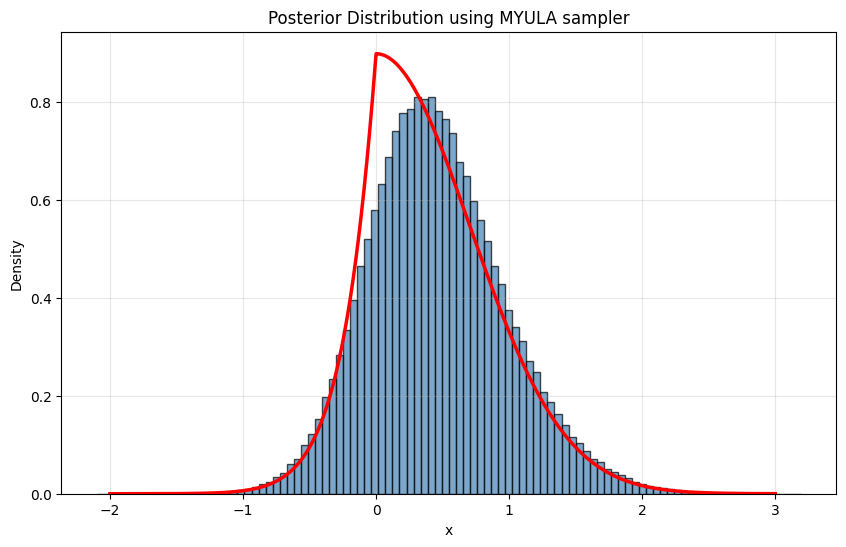

In [4]:
samples_myula = myula_1d(Beta=2.0, Lambda=1.0, Gamma=0.5, step=0.05, n_samples=300000, burn_in=20000)

x_plot = np.linspace(-2, 3, 10000)
y_exact = exact_posterior(x_plot)

plt.figure(figsize=(10, 6))
plt.hist(samples_myula.flatten(), bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='black')
plt.plot(x_plot, y_exact, 'r-', linewidth=2.5, label='Exact Posterior')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Posterior Distribution using MYULA sampler')
plt.grid(True, alpha=0.3)
plt.show()